# Floating Water-Table Example — HYDRUS-1D via phydrus

Single 65-day HYDRUS-1D simulation with a freely-floating water table
(zero bottom-flux boundary). Three consecutive phases in one model run:

| Phase | Days | Top BC | Roots | Purpose |
|-------|------|--------|-------|---------|
| 1 — Warm-up | 0 – 5 | Prec=0, ET=0 | no | let initial conditions relax |
| 2 — Wet | 5 – 35 | Prec=0.80, rSoil=0.03, rRoot=0.01 cm/d | yes | generate shallow ponding and runoff |
| 3 — Dry | 35 – 65 | Prec=0, rSoil=0.08, rRoot=0.02 cm/d | yes | ET + roots → WT drops |


In [1]:
from __future__ import annotations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import phydrus as ps

# ---------------------------------------------------------------------------
# Locate the HYDRUS-1D executable (bundled in this repo under hydrus1d/bin/).
# ---------------------------------------------------------------------------
HYDRUS_EXE = str(Path.cwd().parents[0] / "hydrus1d" / "bin" / "hydrus")

# ---------------------------------------------------------------------------
# Soil column geometry
# ---------------------------------------------------------------------------
Z_TOP = 0.0  # soil surface [cm]
Z_BOT = -300.0  # column bottom [cm]
DX = 10.0  # node spacing [cm]  -> 31 nodes

# ---------------------------------------------------------------------------
# Initial conditions: hydrostatic, water table at Z_WT0
#   h(z) = Z_WT0 - z  ->  negative above WT (unsaturated), positive below (saturated)
# ---------------------------------------------------------------------------
Z_WT0 = -150.0  # initial water-table depth [cm]

# ---------------------------------------------------------------------------
# Van-Genuchten loam parameters  [theta_r, theta_s, alpha, n, Ks, l]
# ---------------------------------------------------------------------------
VG_LOAM = [0.078, 0.43, 0.036, 1.56, 24.96, 0.5]
THETA_S = VG_LOAM[1]  # saturated water content - needed for S = theta/theta_s

# ---------------------------------------------------------------------------
# Observation nodes: depths at which HYDRUS writes head and moisture output
# ---------------------------------------------------------------------------
OBS_Z = [-50.0, -150.0, -250.0]  # [cm] above, at, and below initial WT

# ---------------------------------------------------------------------------
# Phase durations [days]
# ---------------------------------------------------------------------------
T_WARMUP = 5  # Phase 1: zero forcing - let ICs relax
T_WET = 30  # Phase 2: wet forcing -> generate runoff in a stable regime
T_DRY = 30  # Phase 3: no rain, moderate ET -> WT drops
T_TOTAL = T_WARMUP + T_WET + T_DRY  # total simulation length [days] = 65

# Absolute time at which each phase boundary falls - used for plot annotations.
T_P2 = T_WARMUP  # phase 2 starts [day 5]
T_P3 = T_WARMUP + T_WET  # phase 3 starts [day 35]

# ---------------------------------------------------------------------------
# Boundary flux values [cm/day] - named constants for clarity and easy tuning
# ---------------------------------------------------------------------------
PREC_WET = 0.80  # Phase 2 precipitation rate (elevated to trigger runoff)
ESOIL_WET = 0.03  # Phase 2 potential soil evaporation (low - wet conditions)
EROOT_WET = 0.01  # Phase 2 root-water uptake (gentle, still recharge-dominant)
ESOIL_DRY = 0.08  # Phase 3 potential soil evaporation (moderate - dry conditions)
EROOT_DRY = 0.02  # Phase 3 potential root-water uptake (stronger than phase 2)
HCRIT_A = 0.5  # [cm] shallow allowable ponding depth before runoff routing

In [2]:
# ---------------------------------------------------------------------------
# Create the model object
# ---------------------------------------------------------------------------
ws = Path.cwd() / "example_gw"
ws.mkdir(parents=True, exist_ok=True)

ml = ps.Model(
    exe_name=HYDRUS_EXE,
    ws_name=str(ws),
    name="example_gw",
    description="3-phase GW example: warm-up -> wet -> dry",
    mass_units="-",
    time_unit="days",
    length_unit="cm",
    print_screen=False,
)

# ---------------------------------------------------------------------------
# Time discretisation: small initial step, tighter max step for stability.
# ---------------------------------------------------------------------------
ml.add_time_info(tinit=0, tmax=T_TOTAL, print_times=True, dt=0.005, dtmax=0.25, dtprint=1)

# ---------------------------------------------------------------------------
# Water-flow settings.
#   top_bc=3  atmospheric BC throughout - zero flux in Phase 1 is achieved
#             by setting Prec=rSoil=0 in ATMOSPH.IN, not by changing BC type.
#   bot_bc=1  flux BC at base; rbot=0 -> zero flux -> freely-floating WT.
# ---------------------------------------------------------------------------
ml.add_waterflow(
    top_bc=3,
    bot_bc=1,
    rbot=0.0,
    rroot=0.0,
    maxit=30,
    tolh=1.0,
    ha=1e-6,
    hb=1e4,
)

# ---------------------------------------------------------------------------
# Soil material: single homogeneous Van-Genuchten loam layer.
# ---------------------------------------------------------------------------
mat = ml.get_empty_material_df(n=1)
mat.loc[1] = VG_LOAM
ml.add_material(mat)

# ---------------------------------------------------------------------------
# 1-D node profile with hydrostatic initial pressure heads.
#   h(z) = Z_WT0 - z  ->  h < 0 above WT (unsaturated), h > 0 below (saturated)
# ---------------------------------------------------------------------------
profile = ps.create_profile(top=Z_TOP, bot=Z_BOT, dx=DX, mat=1)
profile["h"] = Z_WT0 - profile["x"].to_numpy(float)
ml.add_profile(profile)

# ---------------------------------------------------------------------------
# Observation nodes - HYDRUS writes Obs_Node_* output files for these depths.
# ---------------------------------------------------------------------------
ml.add_obs_nodes(OBS_Z)

In [3]:
# ---------------------------------------------------------------------------
# Build 3-phase atmospheric forcing - one row per day, constant within each phase.
#
#   Phase 1 (days  1 - T_P2):        Prec=0,        rSoil=0,         rRoot=0
#   Phase 2 (days T_P2+1 - T_P3):    Prec=PREC_WET, rSoil=ESOIL_WET, rRoot=EROOT_WET
#   Phase 3 (days T_P3+1 - T_TOTAL): Prec=0,        rSoil=ESOIL_DRY, rRoot=EROOT_DRY
# ---------------------------------------------------------------------------
days = np.arange(1, T_TOTAL + 1, dtype=float)

prec = np.where(days <= T_P2, 0.0, np.where(days <= T_P3, PREC_WET, 0.0))  # [cm/day]

rsoil = np.where(days <= T_P2, 0.0, np.where(days <= T_P3, ESOIL_WET, ESOIL_DRY))

rroot = np.where(days <= T_P2, 0.0, np.where(days <= T_P3, EROOT_WET, EROOT_DRY))

atm = pd.DataFrame(
    {
        "tAtm": days,
        "Prec": prec,
        "rSoil": rsoil,
        "rRoot": rroot,
        "hCritA": np.full_like(days, HCRIT_A),  # low threshold -> excess routed to runoff
        "rB": np.zeros_like(days),
        "hB": np.zeros_like(days),
        "ht": np.zeros_like(days),
    }
)

atm  # show the forcing table

,tAtm,Prec,rSoil,rRoot,hCritA,rB,hB,ht
0,1.0,0.0,0.00,0.00,0.5,0.0,0.0,0.0
1,2.0,0.0,0.00,0.00,0.5,0.0,0.0,0.0
2,3.0,0.0,0.00,0.00,0.5,0.0,0.0,0.0
3,4.0,0.0,0.00,0.00,0.5,0.0,0.0,0.0
4,5.0,0.0,0.00,0.00,0.5,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
60,61.0,0.0,0.08,0.02,0.5,0.0,0.0,0.0
61,62.0,0.0,0.08,0.02,0.5,0.0,0.0,0.0
62,63.0,0.0,0.08,0.02,0.5,0.0,0.0,0.0
63,64.0,0.0,0.08,0.02,0.5,0.0,0.0,0.0


In [4]:
# ---------------------------------------------------------------------------
# Add atmospheric forcing and root-uptake settings, write input, run HYDRUS.
# ---------------------------------------------------------------------------
ml.add_atmospheric_bc(atm)

# S-shaped root uptake (van Genuchten, model=1) is smoother than Feddes and
# generally more numerically stable around saturation transitions.
# poptm is still provided for current phydrus write_selector compatibility.
ml.add_root_uptake(model=1, poptm=[-10], p50=-800, pexp=3)

# Root depth grows linearly from 5 to 60 cm over the full run.
ml.add_root_growth(
    irootin=2,
    irfak=1,
    trmin=0,
    trmed=0,
    trmax=T_TOTAL,
    xrmin=5,
    xrmed=0,
    xrmax=60,
    trperiod=365,
)

ml.write_input()

result = ml.simulate()
if result.returncode != 0:
    raise RuntimeError(f"HYDRUS failed - check {ws}/Error.msg")

print(f"Simulation complete. Outputs in: {ws}")

INFO: Successfully wrote /Users/veethahavya/Desktop/phydrus/examples/example_gw/SELECTOR.IN
INFO: Successfully wrote /Users/veethahavya/Desktop/phydrus/examples/example_gw/PROFILE.DAT
INFO: Successfully wrote /Users/veethahavya/Desktop/phydrus/examples/example_gw/ATMOSPH.IN
INFO: Hydrus-1D Simulation Successful.


Simulation complete. Outputs in: /Users/veethahavya/Desktop/phydrus/examples/example_gw


{'forced_prec_total_cm': 24.0, 'infiltration_total_cm': 0.9014354620000001, 'actual_et_total_cm': 0.9000000000000001, 'non_infiltrated_total_cm': 23.69997, 'ponding_inst_total_cm': 23.39997, 'delayed_infiltration_after_rain_cm': 0.6000300000000001, 'runoff_hydrus_total_cm': 22.8, 'runoff_to_sw_total_cm': 22.8}
Wrote coupling fluxes to: /Users/veethahavya/Desktop/phydrus/examples/example_gw/surface_exchange.csv


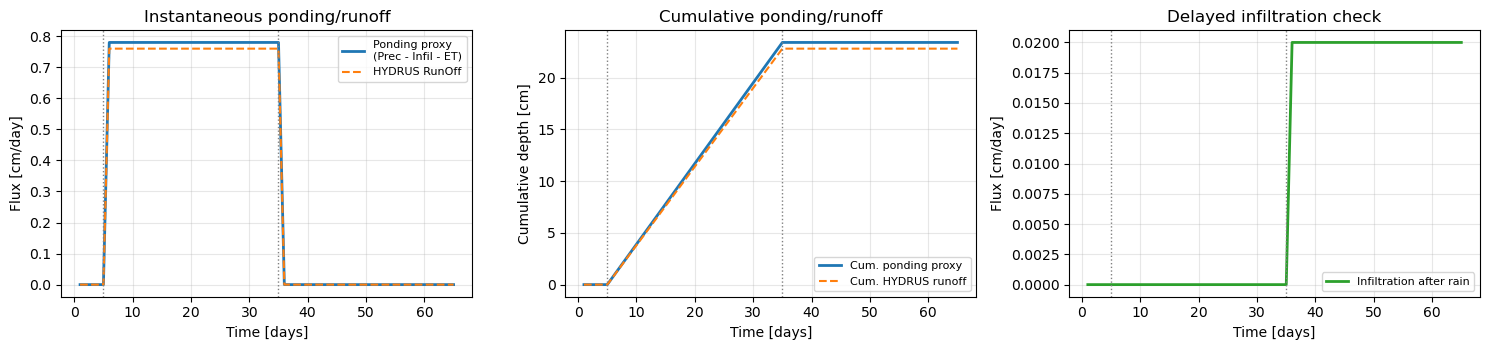

In [5]:
# Surface-water diagnostics after simulation.
# We distinguish three quantities:
# 1) HYDRUS RunOff (true routed runoff),
# 2) non-infiltrated water (Prec - Infiltration),
# 3) instantaneous ponding proxy = Prec - Infiltration - actual ET.
tlevel = ml.read_tlevel().copy()

# Keep only rows with finite times (some outputs may include blank/NaN time rows).
t_all = tlevel.index.to_numpy(dtype=float)
valid = np.isfinite(t_all)
tlevel = tlevel.iloc[np.where(valid)[0]].copy()
t = tlevel.index.to_numpy(dtype=float)

prec_forced = np.interp(
    t,
    atm["tAtm"].to_numpy(dtype=float),
    atm["Prec"].to_numpy(dtype=float),
    left=0.0,
    right=0.0,
)

# HYDRUS sign conventions used here:
# - infiltration at top is negative vTop
# - root uptake is positive vRoot
# - upward evaporative top flux is positive vTop when it occurs
vtop = np.nan_to_num(tlevel["vTop"].to_numpy(dtype=float), nan=0.0)
vroot = np.nan_to_num(tlevel["vRoot"].to_numpy(dtype=float), nan=0.0)

infiltration = np.maximum(-vtop, 0.0)
et_top_actual = np.maximum(vtop, 0.0)
et_root_actual = np.maximum(vroot, 0.0)
et_actual = et_top_actual + et_root_actual

non_infiltrated = np.maximum(prec_forced - infiltration, 0.0)
ponding_inst = np.maximum(prec_forced - infiltration - et_actual, 0.0)

# Time-step widths for cumulative depth [cm].
dt = np.diff(np.r_[0.0, t])
cum_non_infiltrated = np.cumsum(non_infiltrated * dt)
cum_ponding_inst = np.cumsum(ponding_inst * dt)

# HYDRUS native runoff.
has_hydrus_runoff = "RunOff" in tlevel.columns
if has_hydrus_runoff:
    runoff_hydrus = np.nan_to_num(tlevel["RunOff"].to_numpy(dtype=float), nan=0.0)
    cum_runoff_hydrus = np.cumsum(runoff_hydrus * dt)
else:
    runoff_hydrus = np.zeros_like(t)
    cum_runoff_hydrus = np.zeros_like(t)

# Check whether stored surface water appears to be infiltrated later:
# infiltration while precipitation is effectively zero, after the rain phase.
after_rain = (t > T_P3) & (prec_forced < 1e-9)
delayed_infiltration = np.where(after_rain, infiltration, 0.0)
delayed_infiltration_total = float(np.nansum(delayed_infiltration * dt))

# Coupling output for an external surface-water model:
# positive runoff_to_sw means flux leaving HYDRUS to surface-water component.
runoff_to_sw = runoff_hydrus.copy()
cum_runoff_to_sw = np.cumsum(runoff_to_sw * dt)

runoff_df = pd.DataFrame(
    {
        "time_d": t,
        "prec_forced": prec_forced,
        "infiltration": infiltration,
        "et_actual": et_actual,
        "non_infiltrated": non_infiltrated,
        "ponding_inst": ponding_inst,
        "runoff_hydrus": runoff_hydrus,
        "runoff_to_sw": runoff_to_sw,
        "cum_non_infiltrated": cum_non_infiltrated,
        "cum_ponding_inst": cum_ponding_inst,
        "cum_runoff_hydrus": cum_runoff_hydrus,
        "cum_runoff_to_sw": cum_runoff_to_sw,
        "delayed_infiltration": delayed_infiltration,
    }
)

summary = {
    "forced_prec_total_cm": float(np.nansum(prec_forced * dt)),
    "infiltration_total_cm": float(np.nansum(infiltration * dt)),
    "actual_et_total_cm": float(np.nansum(et_actual * dt)),
    "non_infiltrated_total_cm": float(np.nansum(non_infiltrated * dt)),
    "ponding_inst_total_cm": float(np.nansum(ponding_inst * dt)),
    "delayed_infiltration_after_rain_cm": delayed_infiltration_total,
    "runoff_hydrus_total_cm": float(np.nansum(runoff_hydrus * dt)),
    "runoff_to_sw_total_cm": float(np.nansum(runoff_to_sw * dt)),
}

print(summary)
runoff_df.tail()

# Optional export for model coupling.
runoff_df.to_csv(ws / "surface_exchange.csv", index=False)
print(f"Wrote coupling fluxes to: {ws / 'surface_exchange.csv'}")

# Plot diagnostics.
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharex=True)

axes[0].plot(t, ponding_inst, lw=2, label="Ponding proxy\n(Prec - Infil - ET)")
axes[0].plot(t, runoff_hydrus, lw=1.5, ls="--", label="HYDRUS RunOff")
axes[0].set_ylabel("Flux [cm/day]")
axes[0].set_xlabel("Time [days]")
axes[0].set_title("Instantaneous ponding/runoff")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].plot(t, cum_ponding_inst, lw=2, label="Cum. ponding proxy")
axes[1].plot(t, cum_runoff_hydrus, lw=1.5, ls="--", label="Cum. HYDRUS runoff")
axes[1].set_ylabel("Cumulative depth [cm]")
axes[1].set_xlabel("Time [days]")
axes[1].set_title("Cumulative ponding/runoff")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

axes[2].plot(t, delayed_infiltration, lw=2, color="tab:green", label="Infiltration after rain")
axes[2].set_ylabel("Flux [cm/day]")
axes[2].set_xlabel("Time [days]")
axes[2].set_title("Delayed infiltration check")
axes[2].grid(alpha=0.3)
axes[2].legend(fontsize=8)

for ax in axes:
    ax.axvline(T_P2, color="gray", ls=":", lw=1)
    ax.axvline(T_P3, color="gray", ls=":", lw=1)

plt.tight_layout()
plt.show()

## Post-Simulation Diagnostics

Seven diagnostic outputs are shown from the single model run. Vertical dashed lines
mark the phase boundaries at day `T_P2` (=5) and `T_P3` (=35).

1. **Water-table trajectory** - depth of the h=0 contour over the full run
2. **Matric pressure h(t)** at the three observation nodes
3. **Saturation S(t)** at the three observation nodes - $S = \theta / \theta_s$
4. **Profile snapshots** - h(z) and S(z) at end of each phase
5. **Bottom flux** from native phydrus plot - should stay near zero
6. **Native HYDRUS runoff** (`RunOff`) from `T_LEVEL.OUT`
7. **Custom surface partition** including instantaneous ponding proxy:
   - $\max(\mathrm{Prec} - \mathrm{Infil} - \mathrm{ET}_{\mathrm{actual}},\ 0)$
   - delayed infiltration after rainfall to test storage release

In [6]:
# Ensure inline rendering in the notebook.
plt.switch_backend("module://matplotlib_inline.backend_inline")

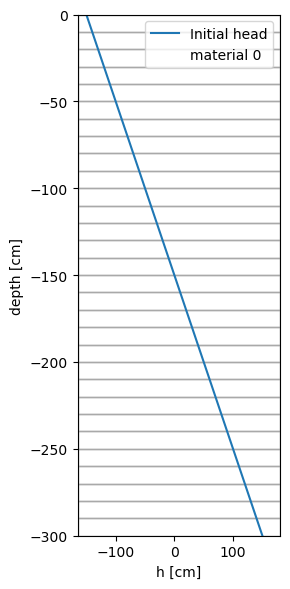

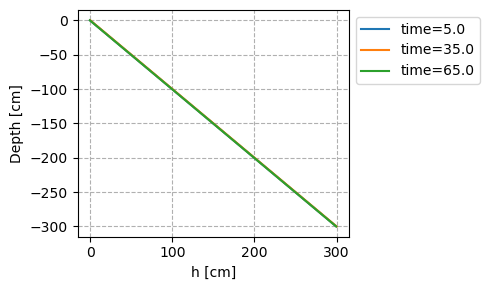

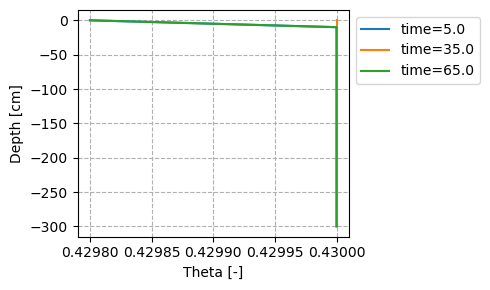

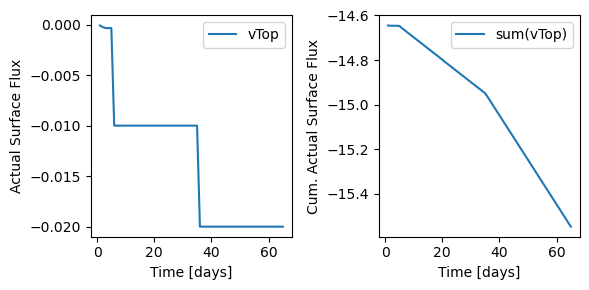

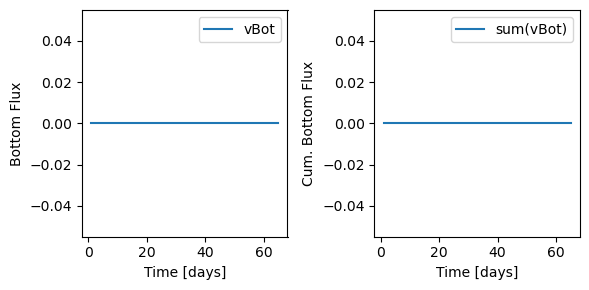

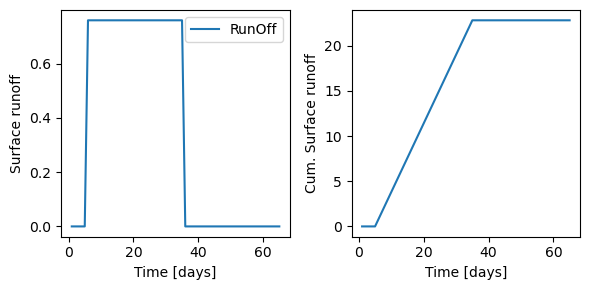

In [7]:
# ---------------------------------------------------------------------------
# phydrus built-in plots  (ml.plots.*)
#
# These use ml's internal state and output files directly - no extra parsing.
# Useful for quick inspection; the custom plots further below give more control.
# ---------------------------------------------------------------------------

# Reload plot module so local changes in phydrus/plot.py are picked up.
import importlib, phydrus.plot as _pp
importlib.reload(_pp)
ml.plots = _pp.Plots(ml=ml)

# Initial soil profile: material layers coloured by Ks, overlaid with IC head.
ml.plots.profile()
plt.show()

# Pressure-head profiles at the end of each phase (reads NOD_INF.OUT).
ml.plots.profile_information(data="Pressure Head", times=[T_P2, T_P3, T_TOTAL])
plt.show()

# Water-content profiles at the same snapshots.
ml.plots.profile_information(data="Water Content", times=[T_P2, T_P3, T_TOTAL])
plt.show()

# Actual surface flux + cumulative over time (reads T-LEVEL.OUT).
ml.plots.water_flow(data="Actual Surface Flux")
plt.show()

# Bottom flux should stay ~0 for the enforced zero bottom-flux boundary.
ml.plots.water_flow(data="Bottom Flux")
plt.show()

# Native HYDRUS runoff (instantaneous + cumulative).
ml.plots.water_flow(data="Surface runoff")
plt.show()

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Helpers used internally by the plot functions below.
# ─────────────────────────────────────────────────────────────────────────────


def _read_nod_inf(ml: ps.Model) -> dict:
    """Read NOD_INF output; normalise to {time_d: DataFrame}."""
    nod = ml.read_nod_inf()
    if isinstance(nod, pd.DataFrame):
        nod = {0.0: nod}
    return nod


def _interpolate_wt(nod: dict) -> pd.DataFrame:
    """
    Interpolate water-table depth from head profiles.
    Returns DataFrame with columns ['Time_d', 'z_wt_cm', 'depth_wt_cm'].
    """
    rows = []
    for t, df in sorted(nod.items()):
        z = df["Depth"].to_numpy(float)
        h = df["Head"].to_numpy(float)
        mask = np.isfinite(z) & np.isfinite(h)
        z, h = z[mask][np.argsort(z[mask])], h[mask][np.argsort(z[mask])]
        sc = np.where(np.diff(np.signbit(h)))[0]
        if sc.size == 0 or np.all(h > 0) or np.all(h < 0):
            rows.append((t, np.nan))
        else:
            i = sc[-1]
            dh = h[i + 1] - h[i]
            z0 = z[i] if abs(dh) < 1e-12 else z[i] + (-h[i]) * (z[i + 1] - z[i]) / dh
            rows.append((t, z0))
    gwl = pd.DataFrame(rows, columns=["Time_d", "z_wt_cm"])
    gwl["depth_wt_cm"] = -gwl["z_wt_cm"]
    return gwl


def _obs_value(df: pd.DataFrame, z_obs: float, col: str) -> float:
    """Value of `col` at the node nearest to depth z_obs."""
    df = df.dropna(subset=["Depth", col]).copy()
    df["Depth"] = df["Depth"].astype(float)
    return float(df.loc[(df["Depth"] - z_obs).abs().idxmin(), col])


def _snap_at(nod: dict, t_target: float) -> pd.DataFrame:
    """NOD_INF snapshot at the time step nearest to t_target."""
    t = min(nod, key=lambda x: abs(x - t_target))
    return nod[t].dropna(subset=["Depth", "Head", "Moisture"]).sort_values("Depth")


def _add_phase_lines(ax):
    """Mark phase boundaries with vertical dotted lines + labels."""
    for t, label in [(T_P2, "→ wet"), (T_P3, "→ dry")]:
        ax.axvline(t, color="gray", ls=":", lw=1.2)
        ax.text(t + 0.4, 1.0, label, transform=ax.get_xaxis_transform(), fontsize=7, color="gray", va="bottom")


# ─────────────────────────────────────────────────────────────────────────────
# Plot 1 — Water-table depth over the full 75-day run
# ─────────────────────────────────────────────────────────────────────────────
def plot_wt_trajectory():
    nod = _read_nod_inf(ml)
    gwl = _interpolate_wt(nod)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(gwl["Time_d"], gwl["depth_wt_cm"], lw=2, color="tab:blue")
    ax.invert_yaxis()
    ax.axhline(abs(Z_WT0), color="k", ls="--", lw=1, label=f"Initial WT ({abs(Z_WT0):.0f} cm depth)")
    _add_phase_lines(ax)
    ax.set(xlabel="Time [days]", ylabel="WT depth below surface [cm]", title="Water-table trajectory")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Plot 2 — Matric pressure h(t) at observation nodes
# ─────────────────────────────────────────────────────────────────────────────
def plot_head_timeseries():
    nod = _read_nod_inf(ml)
    times = sorted(nod.keys())
    fig, ax = plt.subplots(figsize=(9, 4))
    for z_obs in OBS_Z:
        ax.plot(times, [_obs_value(nod[t], z_obs, "Head") for t in times], lw=1.5, label=f"z = {z_obs:.0f} cm")
    ax.axhline(0, color="k", ls="--", lw=1, label="h = 0 (WT)")
    _add_phase_lines(ax)
    ax.set(xlabel="Time [days]", ylabel="h [cm]", title="Matric pressure head at observation nodes")
    ax.legend(fontsize=8, loc="best")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Plot 3 — Saturation S = θ/θs at observation nodes
# ─────────────────────────────────────────────────────────────────────────────
def plot_saturation_timeseries():
    nod = _read_nod_inf(ml)
    times = sorted(nod.keys())
    fig, ax = plt.subplots(figsize=(9, 4))
    for z_obs in OBS_Z:
        ax.plot(
            times, [_obs_value(nod[t], z_obs, "Moisture") / THETA_S for t in times], lw=1.5, label=f"z = {z_obs:.0f} cm"
        )
    _add_phase_lines(ax)
    ax.set(xlabel="Time [days]", ylabel="S = θ/θs [-]", title="Saturation at observation nodes")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, loc="best")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Plot 4 — h(z) and S(z) profiles at the end of each phase
#   h is clipped to H_CLIP to keep scale readable even at wilting point.
# ─────────────────────────────────────────────────────────────────────────────
H_CLIP = (-500, 300)  # display limits for matric pressure h [cm]


def plot_profiles():
    nod = _read_nod_inf(ml)
    snaps = {
        f"IC  (t = 0 d)": _snap_at(nod, 0),
        f"Phase 1  (t = {T_P2} d)": _snap_at(nod, T_P2),
        f"Phase 2  (t = {T_P3} d)": _snap_at(nod, T_P3),
        f"Phase 3  (t = {T_TOTAL} d)": _snap_at(nod, T_TOTAL),
    }
    fig, axes = plt.subplots(2, len(snaps), figsize=(14, 8), sharey=True)
    for j, (label, df) in enumerate(snaps.items()):
        # h(z)
        ax = axes[0, j]
        ax.plot(df["Head"].astype(float).clip(*H_CLIP), df["Depth"].astype(float), lw=2)
        ax.axvline(0, color="k", ls="--", lw=1)
        ax.set_xlim(*H_CLIP)
        ax.set_title(label, fontsize=9)
        ax.set_xlabel("h [cm]")
        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel("Depth [cm]")
        # S(z)
        ax = axes[1, j]
        ax.plot(df["Moisture"].astype(float) / THETA_S, df["Depth"].astype(float), lw=2)
        ax.set_xlim(0, 1.05)
        ax.set_xlabel("S = θ/θs [-]")
        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel("Depth [cm]")
    fig.suptitle("Profile snapshots at end of each phase", fontsize=12)
    fig.tight_layout()
    plt.show()

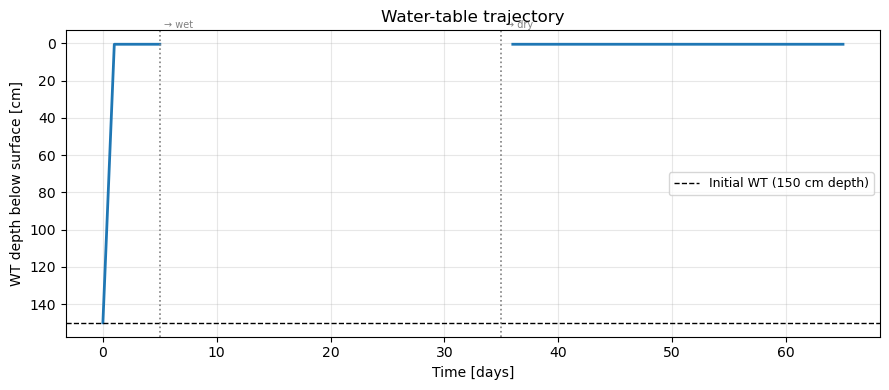

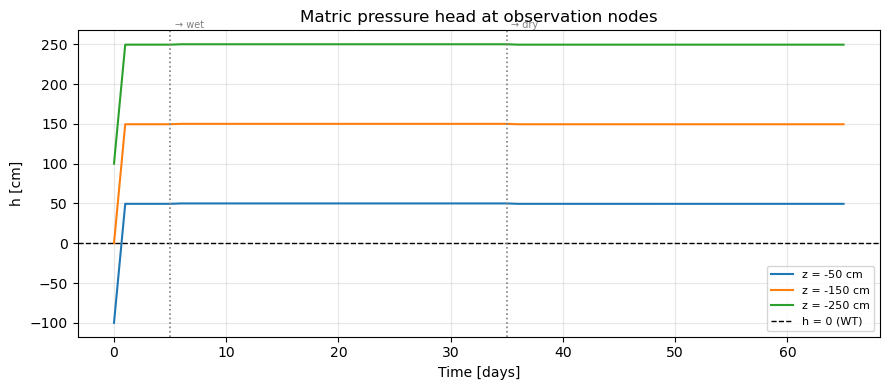

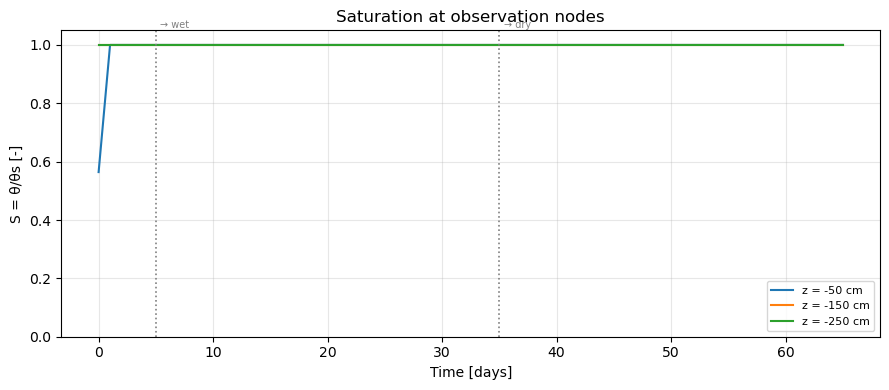

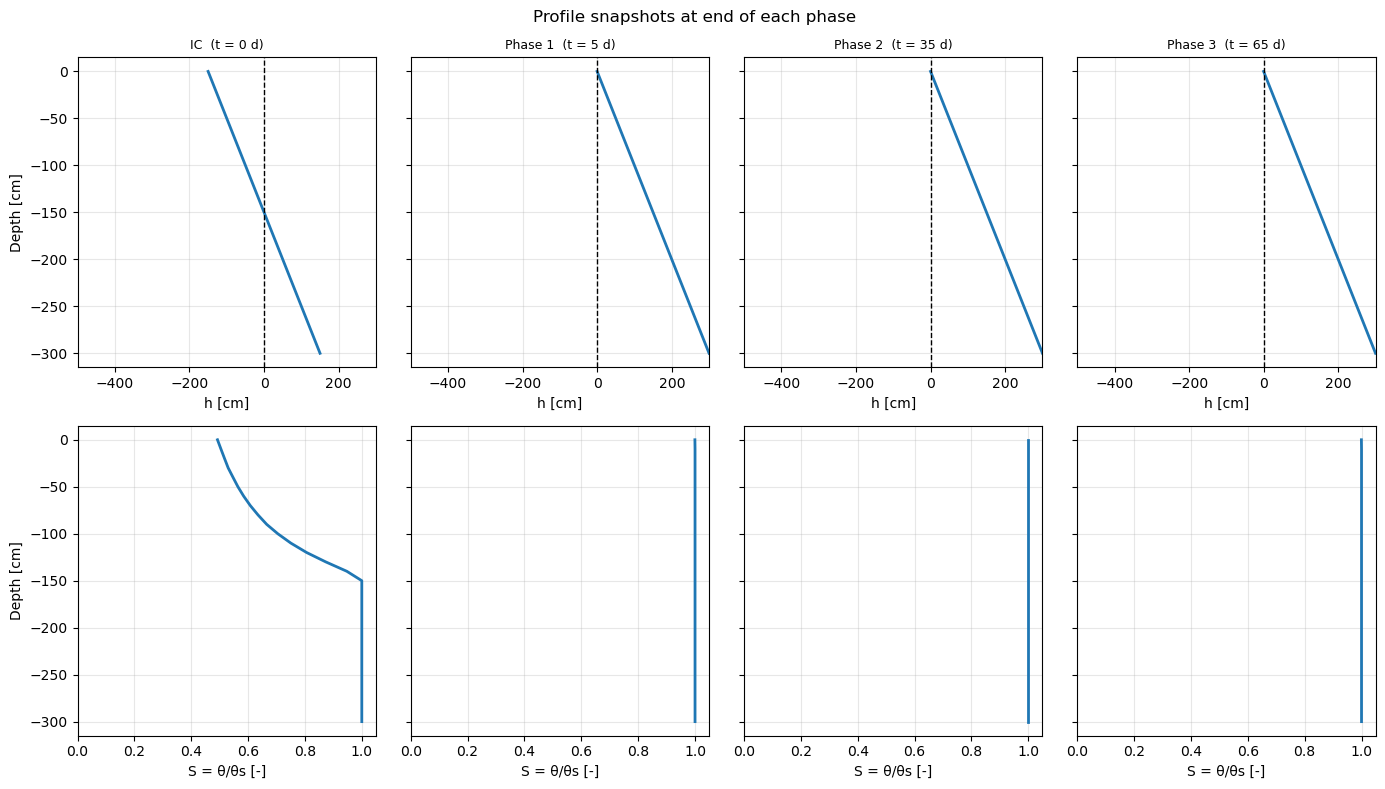

In [9]:
# Run all diagnostic plots.
plot_wt_trajectory()
plot_head_timeseries()
plot_saturation_timeseries()
plot_profiles()